Installing and importing necessary tools.

In [1]:
!pip install pandas numpy scikit-learn scikit-surprise matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Loading downloaded dataset for my project. (Uploaded my dataset to google drive and limited it because it took 5 entire hours to load the first time)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

recommendations = pd.read_csv('/content/drive/MyDrive/recommendations.csv', nrows=100000)
games = pd.read_csv('/content/drive/MyDrive/games.csv')
users = pd.read_csv('/content/drive/MyDrive/users.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Testing to make sure the files are opening correctly.

In [3]:
games.head()
recommendations.head()
users.head()

print("Games:", games.shape)
print("Recommendations:", recommendations.shape)
print("Users:", users.shape)

Games: (50872, 13)
Recommendations: (100000, 8)
Users: (14306064, 3)


Seperating data to only take what I need and showing game titles of games.

In [4]:
df = recommendations.copy()

df['rating'] = df['is_recommended'].astype(int)

df = df[['user_id', 'app_id', 'rating']]

df = df.merge(games[['app_id', 'title']], on='app_id', how='left')

df.head()

,user_id,app_id,rating,title
0,51580,975370,1,Dwarf Fortress
1,2586,304390,0,FOR HONOR™
2,253880,1085660,1,Destiny 2
3,259432,703080,1,Planet Zoo
4,23869,526870,1,Satisfactory


Creating graph to see what games are the most played.

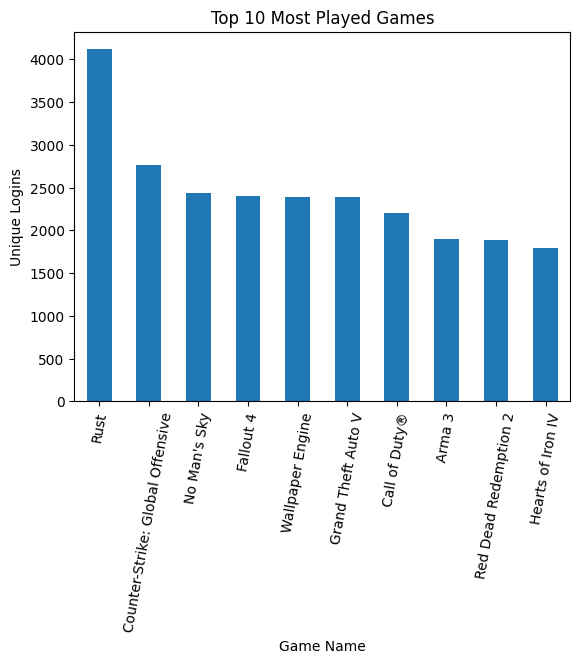

In [9]:
top_games = df['title'].value_counts().head(10)

plt.figure()
top_games.plot(kind='bar')
plt.title("Top 10 Most Played Games")
plt.xlabel("Game Name")
plt.ylabel("Unique Logins")
plt.xticks(rotation=80)
plt.show()

Telling the model what statistics to look at, those being the same ones I limited the loading to earlier. (Used Gemini here because I could not get it to runm turns out I was just missing the install)

In [10]:
!pip install "numpy<2"
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0, 1))
data = Dataset.load_from_df(df[['user_id', 'app_id', 'rating']], reader)

Training and testingthe model to produce the proper results with a model well suited to the task.

In [13]:
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2)


from surprise import SVD

model = SVD()
model.fit(trainset)

In [14]:
from surprise import accuracy

predictions = model.test(testset)
rmse = accuracy.rmse(predictions)

print("RMSE:", rmse)

RMSE: 0.3428
RMSE: 0.34275730804984517


Generating random results with the training results.

In [15]:
user_id = df['user_id'].iloc[0]

all_games = df['app_id'].unique()

played_games = df[df['user_id'] == user_id]['app_id'].values

game_id_to_name = dict(zip(games['app_id'], games['title']))

recommendations_list = []

for game in all_games:
    if game not in played_games:
        pred = model.predict(user_id, game)
        game_name = game_id_to_name.get(game, "Unknown")
        recommendations_list.append((game_name, pred.est))

recommendations_list.sort(key=lambda x: x[1], reverse=True)

top_10 = recommendations_list[:10]
top_10

[('Hades', 1),
 ('Marvel’s Spider-Man Remastered', 1),
 ('Terraria', 1),
 ('DARK SOULS™: REMASTERED', 1),
 ('The Binding of Isaac: Rebirth', 1),
 ('Warframe', 1),
 ('Planet Coaster', 1),
 ('American Truck Simulator', 1),
 ('Raft', 1),
 ('Ready or Not', 1)]

Reflection: Cannot get proper results for someone with no games played, unavoidable issue. Limited to 1 and 0 for rating, would have to also make weights for the average steam ratings per game which are inconsistent on steam (Ex. Overwatch is rate mostly negative yet has a consistent decently high player count). Could add game metadata but I am uncertain of how to implement it into the model.